In [18]:
# Licensed under a 3-clause BSD style license - see LICENSE.rst
from pydantic import ValidationError
from gammapy.io.core import ProductReaderWriter
from gammapy.io.gadf import GADFHDUListReaderWriter
import logging, sys

root = logging.getLogger()
root.handlers.clear()                        # start clean (avoids duplicates on re-run)
root.setLevel(logging.INFO)

fmt = logging.Formatter('%(asctime)s,%(msecs)03d %(name)s %(levelname)s %(message)s',
                        '%Y-%m-%d %H:%M:%S')

console_h = logging.StreamHandler(sys.stdout)
console_h.setFormatter(fmt)
root.addHandler(console_h)

paths_to_test = [
    "gammapy/gammapy-datasets/dev/cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits",
    "gammapy/gammapy-datasets/dev/cta-1dc/data/baseline/gps/gps_baseline_110380.fits",
    "gammapy/gammapy-datasets/dev/cta-caldb/Prod5-North-20deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz",
    "gammapy/gammapy-datasets/dev/fermi_3fhl/fermi_3fhl_events_selected.fits.gz",
    "gammapy/gammapy-datasets/dev/fermi_3fhl/fermi_3fhl_psf_gc.fits.gz",
    "gammapy/gammapy-datasets/dev/fermi-3fhl-crab/Fermi-LAT-3FHL_data_Fermi-LAT.fits",
    "gammapy/gammapy-datasets/dev/fermi-3fhl-crab/Fermi-LAT-3FHL_iem.fits",
    "gammapy/gammapy-datasets/dev/fermi-3fhl-gc/fermi-3fhl-gc-events.fits.gz",
    "gammapy/gammapy-datasets/dev/fermi-3fhl-gc/fermi-3fhl-gc-psf.fits.gz",
    "gammapy/gammapy-datasets/dev/fermi-gc/drm_01.fits",
    "gammapy/gammapy-datasets/dev/fermi-gc/psf_01.fits",
    "gammapy/gammapy-datasets/dev/hawc/crab_events_pass4/events/EventList_Crab_fHitbin5GP.fits.gz",
    "gammapy/gammapy-datasets/dev/hawc/crab_events_pass4/irfs/EDispKernelMap_Crab_fHitbin5GP.fits.gz",
    "gammapy/gammapy-datasets/dev/hawc/crab_events_pass4/irfs/EffectiveAreaMap_Crab_fHitbin8GP.fits.gz",
    "gammapy/gammapy-datasets/dev/hawc/crab_events_pass4/irfs/PSFMap_Crab_fHitbin5GP.fits.gz",
    "gammapy/gammapy-datasets/dev/hess-dl3-dr1/data/hess_dl3_dr1_obs_id_021613.fits.gz",
    "gammapy/gammapy-datasets/dev/joint-crab/dl3/magic/run_05029748_DL3.fits",
    "gammapy/gammapy-datasets/dev/magic/rad_max/data/20131004_05029747_DL3_CrabNebula-W0.40+035.fits",
    "gammapy/gammapy-datasets/dev/PKS2155-steady/pks2155-304_steady.fits.gz",
    "gammapy/gammapy-datasets/dev/veritas/crab-point-like-ED/64080.fits.gz"
]

In [2]:
filename="$GAMMAPY_DATA/hess-dl3-dr1/data/hess_dl3_dr1_obs_id_020136.fits.gz"

strict = True
verbose = True

rw = GADFHDUListReaderWriter.read(filename, strict=strict, verbose=verbose)
rw.hdu_dict

2026-07-22 16:36:32,385 gammapy.io.core INFO 
------------------------------------------------
/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/hess-dl3-dr1/data/hess_dl3_dr1_obs_id_020136.fits.gz 
TESTED FMT: GADF VER: 0.3 (strict=True)
2026-07-22 16:36:32,551 gammapy.io.core INFO Reading EVENTS HDU
2026-07-22 16:36:32,554 gammapy.io.core INFO Reading GTI HDU
2026-07-22 16:36:32,557 gammapy.io.core INFO Reading RESPONSE HDU (AEFF_2D)
2026-07-22 16:36:32,564 gammapy.io.core INFO Reading RESPONSE HDU (EDISP_2D)
2026-07-22 16:36:32,570 gammapy.io.core INFO Reading RESPONSE HDU (PSF_TABLE)
2026-07-22 16:36:32,580 gammapy.io.core INFO Reading RESPONSE HDU (BKG_3D)
2026-07-22 16:36:32,580 gammapy.io.core INFO 
HDU       FMT  VER HDR TAB
EVENTS    GADF 0.2 OK OK
GTI       GADF 0.2 OK OK
EFF_AREA  GADF 0.2 OK OK
EDISP     GADF 0.2 OK OK
RPSF      GADF 0.2 OK OK
BKG       GADF 0.2 OK OK


{'PRIMARY': <gammapy.io.core.HDUReaderWriter at 0x179b44810>,
 'EVENTS': <gammapy.io.gadf.GADFEventsReaderWriter at 0x17cfbbad0>,
 'GTI': <gammapy.io.gadf.GADFGTIReaderWriter at 0x17e4a4410>,
 'EFF_AREA': <gammapy.io.gadf.GADFResponseReaderWriter at 0x17db57590>,
 'EDISP': <gammapy.io.gadf.GADFResponseReaderWriter at 0x17e4c1cd0>,
 'RPSF': <gammapy.io.gadf.GADFResponseReaderWriter at 0x17e4a8c90>,
 'BKG': <gammapy.io.gadf.GADFResponseReaderWriter at 0x17ea0a6d0>}

In [3]:
rw.hdu_dict['EDISP']

In [4]:
rw.hdu_dict['EDISP'].header

GADFResponseHeader(TELESCOP='HESS', INSTRUME='H.E.S.S. Phase I', ORIGIN='H.E.S.S. Collaboration', CREATOR=None, HDUCLAS2='EDISP', HDUCLAS3='FULL-ENCLOSURE', HDUCLAS4='EDISP_2D', HDUCLASS='GADF', comments=['This file is part of the first H.E.S.S. FITS test data release from 2018', 'Webpage: https://www.mpi-hd.mpg.de/hfm/HESS/pages/dl3-dr1/', 'Contact: contact@hess-experiment.eu.'], history=None, HDUVERS='0.2', HDUDOC='https://github.com/open-gamma-ray-astro/gamma-astro-data-formats', HDUCLAS1='RESPONSE', EXTNAME='EDISP', OBS_ID=None, LO_THRES=None, HI_THRES=None, FOVALIGN=None)

In [5]:
rw.hdu_dict['EDISP'].header.to_meta()

{'TELESCOP': 'HESS',
 'INSTRUME': 'H.E.S.S. Phase I',
 'ORIGIN': 'H.E.S.S. Collaboration',
 'HDUCLAS2': 'EDISP',
 'HDUCLAS3': 'FULL-ENCLOSURE',
 'HDUCLAS4': 'EDISP_2D',
 'HDUCLASS': 'GADF',
 'comments': ['This file is part of the first H.E.S.S. FITS test data release from 2018',
  'Webpage: https://www.mpi-hd.mpg.de/hfm/HESS/pages/dl3-dr1/',
  'Contact: contact@hess-experiment.eu.'],
 'HDUVERS': '0.2',
 'HDUDOC': 'https://github.com/open-gamma-ray-astro/gamma-astro-data-formats',
 'HDUCLAS1': 'RESPONSE',
 'EXTNAME': 'EDISP',
 'EV_CLASS': 'std',
 'CREF7': '(ENERG_LO:ENERG_HI,MIGRA_LO:MIGRA_HI,THETA_LO:THETA_HI)'}

In [6]:
rw.hdu_dict['EDISP'].table

ENERG_LO,ENERG_HI,MIGRA_LO,MIGRA_HI,THETA_LO,THETA_HI,MATRIX
TeV,TeV,,,deg,deg,
float32[96],float32[96],float32[160],float32[160],float32[6],float32[6],"float32[6,160,96]"
0.01 .. 90.85179,0.011006941 .. 100.0,0.2 .. 4.97,0.23 .. 5.0,0.0 .. 2.5,0.0 .. 2.5,0.0 .. 0.0


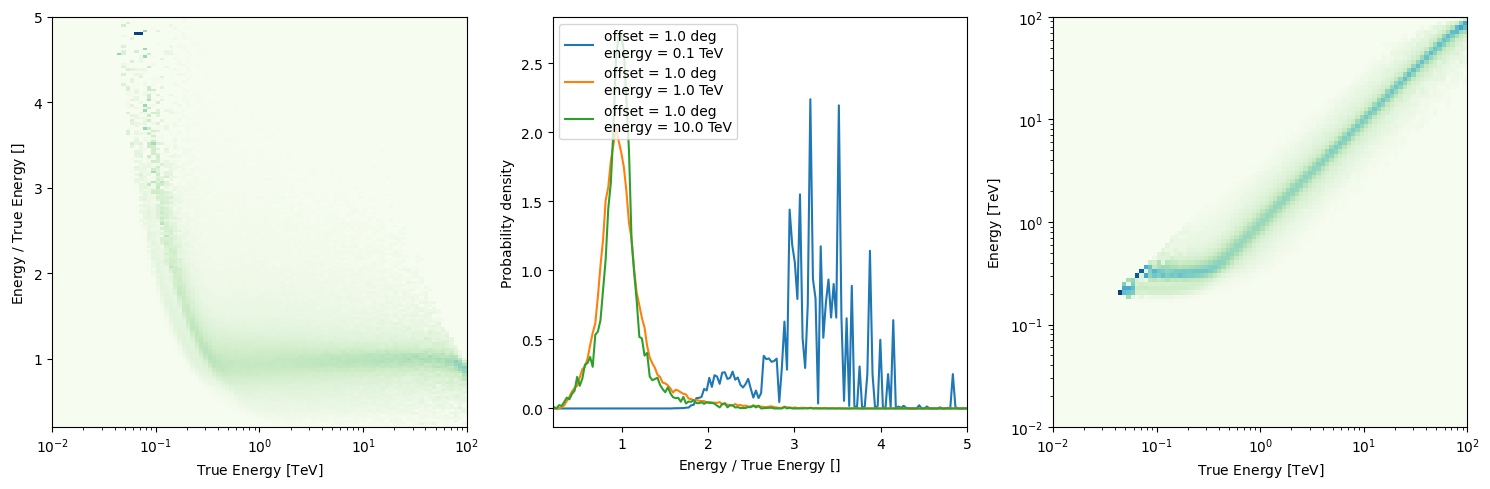

In [7]:
edisp = rw.hdu_dict['EDISP'].to_product()
edisp.peek()

In [8]:
products = rw.to_product_dict()
display(products)

{'events': <gammapy.data.event_list.EventList at 0x10dee74d0>,
 'gti': <gammapy.data.gti.GTI at 0x17f0802d0>,
 'aeff': <gammapy.irf.effective_area.EffectiveAreaTable2D at 0x17e4a8090>,
 'edisp': <gammapy.irf.edisp.core.EnergyDispersion2D at 0x17f081d50>,
 'psf': <gammapy.irf.psf.table.PSF3D at 0x17ea8ae90>,
 'bkg': <gammapy.irf.background.Background3D at 0x17efda950>,
 'pointing': <gammapy.data.pointing.FixedPointingInfo at 0x17ef74c90>}

2026-07-22 16:36:33,054 gammapy.io.core INFO 
------------------------------------------------
/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/hess-dl3-dr1/data/hess_dl3_dr1_obs_id_020136.fits.gz 
TESTED FMT: GADF VER: 0.3 (strict=False)
2026-07-22 16:36:33,071 gammapy.io.core INFO Reading EVENTS HDU
2026-07-22 16:36:33,078 gammapy.io.core INFO Reading GTI HDU
2026-07-22 16:36:33,087 gammapy.io.core INFO Reading RESPONSE HDU (AEFF_2D)
2026-07-22 16:36:33,097 gammapy.io.core INFO Reading RESPONSE HDU (EDISP_2D)
2026-07-22 16:36:33,103 gammapy.io.core INFO Reading RESPONSE HDU (PSF_TABLE)
2026-07-22 16:36:33,112 gammapy.io.core INFO Reading RESPONSE HDU (BKG_3D)
2026-07-22 16:36:33,114 gammapy.io.core INFO 
HDU       FMT  VER HDR TAB
EVENTS    GADF 0.2 OK OK
GTI       GADF 0.2 OK OK
EFF_AREA  GADF 0.2 OK OK
EDISP     GADF 0.2 OK OK
RPSF      GADF 0.2 OK OK
BKG       GADF 0.2 OK OK


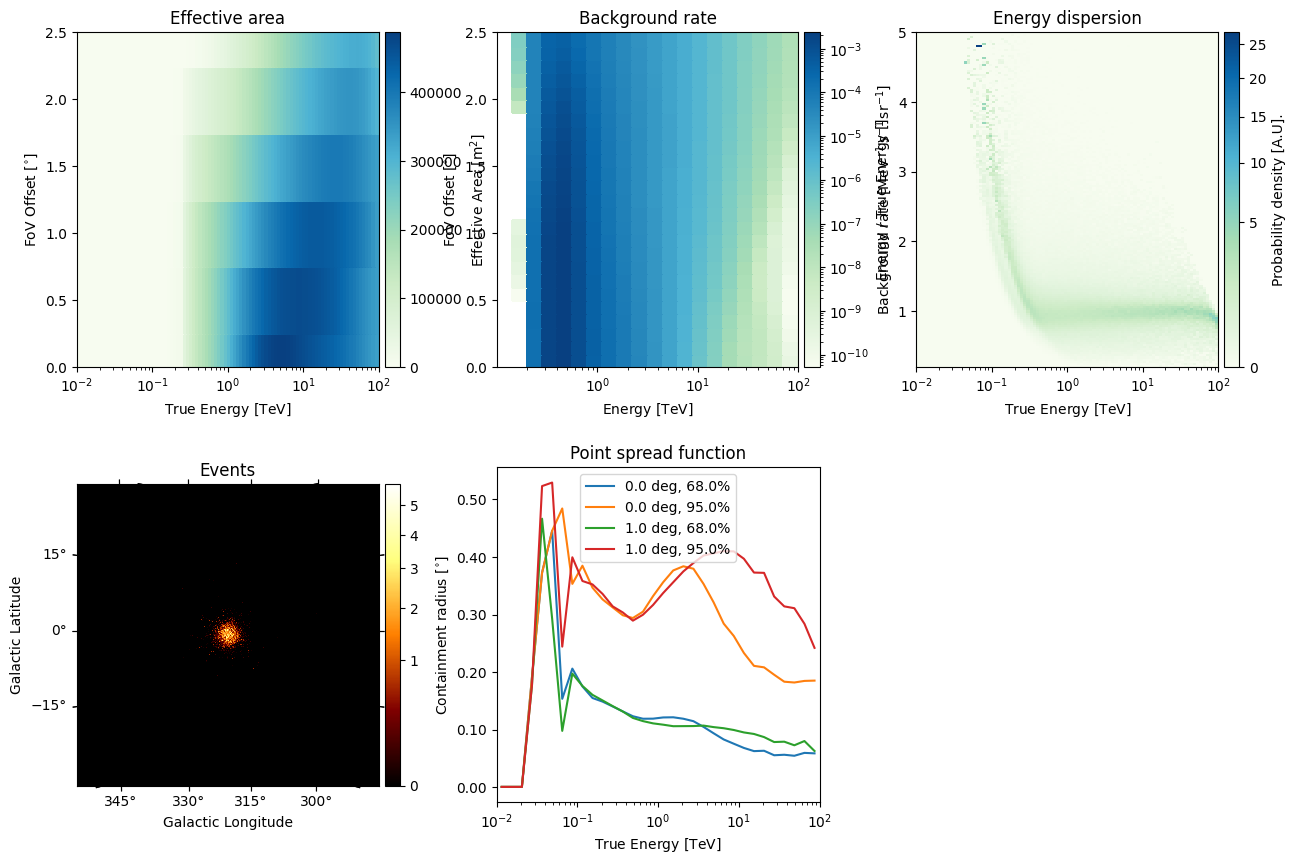

In [9]:
from gammapy.data import Observation

# Observation.read() uses rw.read() and rw.to_product_dict()
obs = Observation.read(filename)
obs.peek()

In [10]:
# rw.to_hdulist calls ._to_hdu() on each individual HDU reader/writer, where the validation is done
hdul = rw.to_hdulist(strict=strict)
hdul

2026-07-22 16:36:33,837 gammapy.io.core INFO HDU: EVENTS      TEST FMT: GADF VER: 0.3 HDR: OK TAB: OK
2026-07-22 16:36:33,839 gammapy.io.core INFO HDU: GTI         TEST FMT: GADF VER: 0.3 HDR: OK TAB: OK
2026-07-22 16:36:33,843 gammapy.io.core INFO HDU: AEFF_2D     TEST FMT: GADF VER: 0.3 HDR: OK TAB: OK
2026-07-22 16:36:33,846 gammapy.io.core INFO HDU: EDISP_2D    TEST FMT: GADF VER: 0.3 HDR: OK TAB: OK
2026-07-22 16:36:33,850 gammapy.io.core INFO HDU: PSF_TABLE   TEST FMT: GADF VER: 0.3 HDR: OK TAB: OK
2026-07-22 16:36:33,853 gammapy.io.core INFO HDU: BKG_3D      TEST FMT: GADF VER: 0.3 HDR: OK TAB: OK


In [11]:
# rw.write() cals rw.to_hdulist() to serialize
filename_out = "./hdulist.fits.gz"
rw.write(filename_out, overwrite=True, strict=True)

2026-07-22 16:36:33,864 gammapy.io.core INFO HDU: EVENTS      TEST FMT: GADF VER: 0.3 HDR: OK TAB: OK
2026-07-22 16:36:33,866 gammapy.io.core INFO HDU: GTI         TEST FMT: GADF VER: 0.3 HDR: OK TAB: OK
2026-07-22 16:36:33,869 gammapy.io.core INFO HDU: AEFF_2D     TEST FMT: GADF VER: 0.3 HDR: OK TAB: OK
2026-07-22 16:36:33,873 gammapy.io.core INFO HDU: EDISP_2D    TEST FMT: GADF VER: 0.3 HDR: OK TAB: OK
2026-07-22 16:36:33,877 gammapy.io.core INFO HDU: PSF_TABLE   TEST FMT: GADF VER: 0.3 HDR: OK TAB: OK
2026-07-22 16:36:33,881 gammapy.io.core INFO HDU: BKG_3D      TEST FMT: GADF VER: 0.3 HDR: OK TAB: OK


2026-07-22 16:36:33,998 gammapy.io.core INFO 
------------------------------------------------
hdulist.fits.gz 
TESTED FMT: GADF VER: 0.3 (strict=False)
2026-07-22 16:36:34,004 gammapy.io.core INFO Reading EVENTS HDU
2026-07-22 16:36:34,006 gammapy.io.core INFO Reading GTI HDU
2026-07-22 16:36:34,009 gammapy.io.core INFO Reading RESPONSE HDU (AEFF_2D)
2026-07-22 16:36:34,016 gammapy.io.core INFO Reading RESPONSE HDU (EDISP_2D)
2026-07-22 16:36:34,022 gammapy.io.core INFO Reading RESPONSE HDU (PSF_TABLE)
2026-07-22 16:36:34,028 gammapy.io.core INFO Reading RESPONSE HDU (BKG_3D)
2026-07-22 16:36:34,029 gammapy.io.core INFO 
HDU       FMT  VER HDR TAB
EVENTS    GADF 0.2 OK OK
GTI       GADF 0.2 OK OK
EFF_AREA  GADF 0.2 OK OK
EDISP     GADF 0.2 OK OK
RPSF      GADF 0.2 OK OK
BKG       GADF 0.2 OK OK


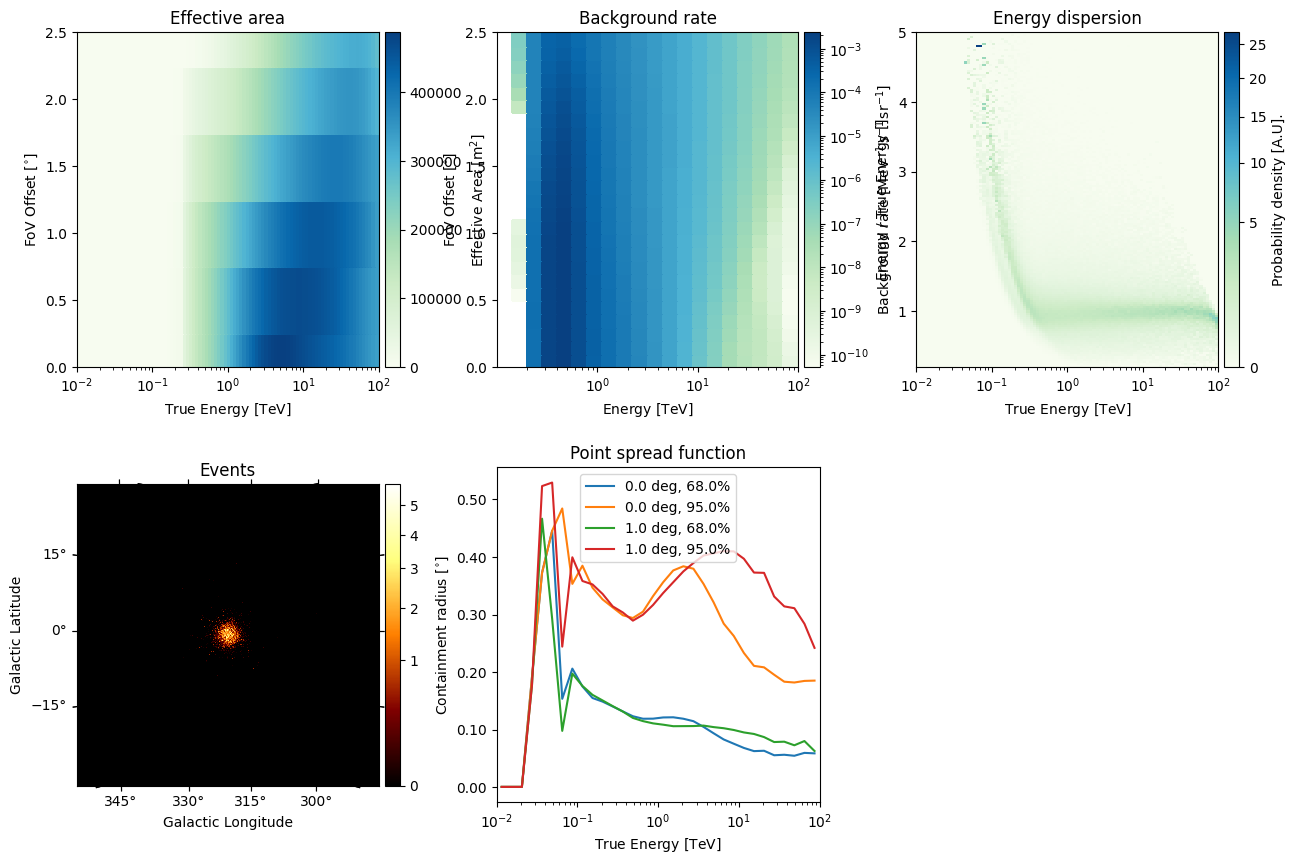

In [12]:
obs = Observation.read(filename_out)
obs.peek()

In [13]:
from gammapy.data import DataStore
data_store = DataStore.from_dir("$GAMMAPY_DATA/hess-dl3-dr1")

print(data_store.info())

Data store:
HDU index table:
BASE_DIR: /Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/hess-dl3-dr1
Rows: 630
OBS_ID: 20136 -- 47829
HDU_TYPE: ['aeff', 'bkg', 'edisp', 'events', 'gti', 'psf']
HDU_CLASS: ['aeff_2d', 'bkg_3d', 'edisp_2d', 'events', 'gti', 'psf_table']


Observation table:
Observatory name: 'N/A'
Number of observations: 105

None


2026-07-22 16:36:34,685 gammapy.data.data_store INFO Observations selected: 105 out of 105.
2026-07-22 16:36:34,718 gammapy.io.core INFO 
------------------------------------------------
/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/hess-dl3-dr1/data/hess_dl3_dr1_obs_id_020136.fits.gz 
TESTED FMT: GADF VER: 0.3 (strict=False)
2026-07-22 16:36:34,727 gammapy.io.core INFO Reading EVENTS HDU
2026-07-22 16:36:34,731 gammapy.io.core INFO Reading GTI HDU
2026-07-22 16:36:34,735 gammapy.io.core INFO Reading RESPONSE HDU (AEFF_2D)
2026-07-22 16:36:34,743 gammapy.io.core INFO Reading RESPONSE HDU (EDISP_2D)
2026-07-22 16:36:34,749 gammapy.io.core INFO Reading RESPONSE HDU (PSF_TABLE)
2026-07-22 16:36:34,756 gammapy.io.core INFO Reading RESPONSE HDU (BKG_3D)
2026-07-22 16:36:34,756 gammapy.io.core INFO 
HDU       FMT  VER HDR TAB
EVENTS    GADF 0.2 OK OK
GTI       GADF 0.2 OK OK
EFF_AREA  GADF 0.2 OK OK
EDISP     GADF 0.2 OK OK
RPSF      GADF 0.2 OK OK
BKG       GADF 0.2 OK OK
2026-07-22 16

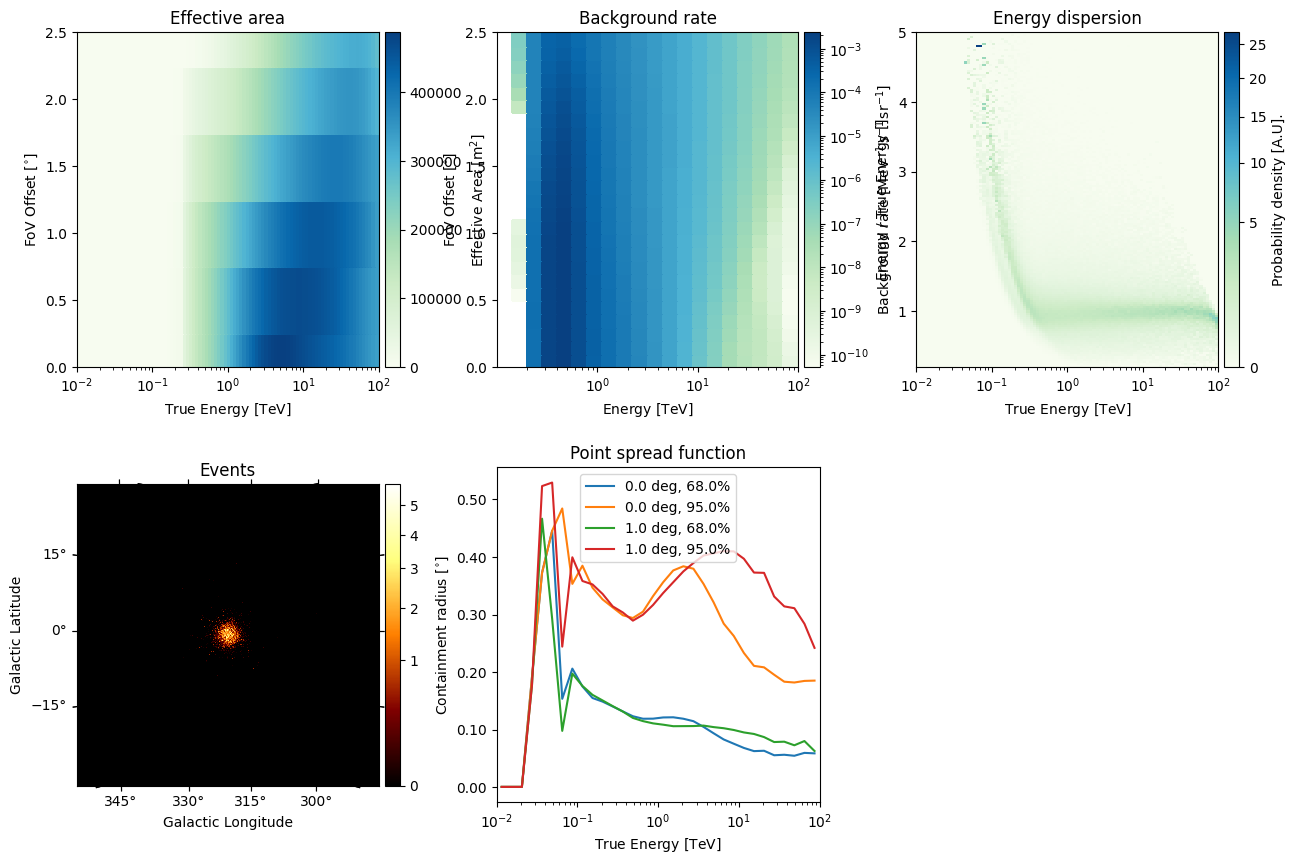

In [14]:
# data_store.get_observations() calls gammapy.fits.HDULocation.load(), which now calls rw.read() instead of fits.open as hdulist
obs_collection = data_store.get_observations()
obs_collection[0].peek()

2026-07-22 16:36:35,658 gammapy.io.core INFO 
------------------------------------------------
/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/hawc/crab_events_pass4/background/BackgroundMap_Crab_fHitbin6NN.fits.gz 
TESTED FMT: GADF VER: 0.3 (strict=False)
2026-07-22 16:36:35,666 gammapy.io.core INFO Reading BANDS HDU
2026-07-22 16:36:35,667 gammapy.io.core WARNING Table not compliant: table: CHANNEL: Column ndim incorrect. Expected 1, got 0.; E_MIN: Column ndim incorrect. Expected 1, got 0.; E_MAX: Column ndim incorrect. Expected 1, got 0.; ENERGY: Column ndim incorrect. Expected 1, got 0.
2026-07-22 16:36:35,667 gammapy.io.core INFO 
HDU            FMT  VER HDR TAB
PRIMARY_BANDS  GADF 0.3 OK FAIL
2026-07-22 16:36:35,667 gammapy.io.gadf WARNING IRF reconstruction failed for hdu='BKG', hdu_class=None (KeyError: 'No object found with tag: None'); falling back to Map.read.


<WCSAxes: >

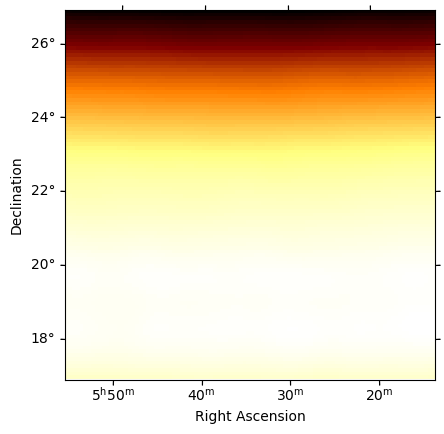

In [15]:
# Multi HDU objects like maps are also implemented, although the validation still needs some work regarding keyword mapping for the tables
rw_2 = GADFHDUListReaderWriter.read("/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/hawc/crab_events_pass4/background/BackgroundMap_Crab_fHitbin6NN.fits.gz")

rw_2.to_map().sum_over_axes(['energy']).plot()

In [16]:
# You can see the GADFBandsHeader validating a BANDS HDU. None populated keywords will get dropped by .to_meta()
rw_2.hdu_dict['PRIMARY_BANDS'].header

GADFBandsHeader(HDUCLASS='GADF', comments=None, history=None, HDUVERS='0.3', HDUDOC=None, HDUCLAS1='BANDS')

In [19]:
# The ProductReaderWriter is intended to be the only interface between the user and gammapy products, with the least amount of needed knowledge possible. Format is inferred and tested against default (GADF v0.3).

filename_i = "$GAMMAPY_DATA/hawc/crab_events_pass4/events/EventList_Crab_fHitbin5GP.fits.gz"


events = ProductReaderWriter(filename_i, 'EVENTS').product
# Eventually, the idea is to let the code handle the HDU class keywords, with EventsReaderWriter, IRFReaderWriter, MapDatasetReaderWriter, etc

2026-07-22 16:37:34,646 gammapy.io.core INFO 
------------------------------------------------
/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/hawc/crab_events_pass4/events/EventList_Crab_fHitbin5GP.fits.gz 
TESTED FMT: GADF VER: 0.3 (strict=False)
2026-07-22 16:37:34,684 gammapy.io.core INFO Reading EVENTS HDU
2026-07-22 16:37:34,685 gammapy.io.core WARNING Missing mandatory keyword(s): ['ORIGIN']
2026-07-22 16:37:34,687 gammapy.io.gadf WARNING Non-standard HDUVERS 'dev1bf00373'; known: ['0.2', '0.3']
2026-07-22 16:37:34,705 gammapy.io.core INFO Reading GTI HDU
2026-07-22 16:37:34,706 gammapy.io.core WARNING Table not compliant: table: START: Column unit incorrect. Expected s, got None.; STOP: Column unit incorrect. Expected s, got None.
2026-07-22 16:37:34,706 gammapy.io.core INFO 
HDU      FMT  VER         HDR  TAB
EVENTS   GADF dev1bf00373 FAIL OK
GTI      GADF 0.3         OK   FAIL


In [20]:
# Here is a loop on files from gammapy extra datasets to check the data formats
# Testing against GADF, all other detected formats will default to specific HDUReader if the format is handled, else to generic HDUReaderWriter without validation. 
# If no format is detected, GADF is tested by default, but if the HDU is not in the registry it defaults to a generic HDUReaderWriter.

strict = False
version = "0.3"
verbose=True
for ipath, path in enumerate(paths_to_test):
    filename_i = "$GAMMAPY_DATA" + path[28:]
    print(f"----------------------------\n{ipath}: {filename_i}", flush=True)
    rw_3 = GADFHDUListReaderWriter.read(filename_i, strict=strict, version=version, verbose=verbose)
    display(rw_3.hdu_dict)

----------------------------
0: $GAMMAPY_DATA/cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits
2026-07-22 16:37:34,717 gammapy.io.core INFO 
------------------------------------------------
/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits 
TESTED FMT: GADF VER: 0.3 (strict=False)
2026-07-22 16:37:34,728 gammapy.io.core INFO Reading RESPONSE HDU (AEFF_2D)
2026-07-22 16:37:34,734 gammapy.io.core INFO Reading RESPONSE HDU (PSF_3GAUSS)
2026-07-22 16:37:34,737 gammapy.io.core WARNING Table not compliant: table: SCALE: Column unit incorrect. Expected 1 / sr, got None.
2026-07-22 16:37:34,744 gammapy.io.core INFO Reading RESPONSE HDU (EDISP_2D)
2026-07-22 16:37:34,747 gammapy.io.core WARNING Table not compliant: table: missing required column 'ENERG_LO'; missing required column 'ENERG_HI'
2026-07-22 16:37:34,758 astropy WARNING UnitsWarning: '1/s/MeV/sr' did not parse as fits unit: Numeric factor not supported by FITS If t

{'PRIMARY': <gammapy.io.core.HDUReaderWriter at 0x306c1c550>,
 'EFF_AREA': <gammapy.io.gadf.GADFResponseReaderWriter at 0x307219290>,
 'RPSF': <gammapy.io.gadf.GADFResponseReaderWriter at 0x306cd6090>,
 'EDISP': <gammapy.io.gadf.GADFResponseReaderWriter at 0x3057da3d0>,
 'BKG': <gammapy.io.gadf.GADFResponseReaderWriter at 0x306eb4c90>}

----------------------------
1: $GAMMAPY_DATA/cta-1dc/data/baseline/gps/gps_baseline_110380.fits
2026-07-22 16:37:34,769 gammapy.io.core INFO 
------------------------------------------------
/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/cta-1dc/data/baseline/gps/gps_baseline_110380.fits 
TESTED FMT: GADF VER: 0.3 (strict=False)
2026-07-22 16:37:34,783 gammapy.io.core INFO Reading EVENTS HDU
2026-07-22 16:37:34,784 gammapy.io.core WARNING Missing mandatory keyword(s): ['ORIGIN', 'HDUVERS', 'INSTRUME', 'HDUCLAS1', 'HDUDOC', 'HDUCLASS', 'OBS_MODE']
2026-07-22 16:37:34,790 gammapy.io.core INFO Reading GTI HDU
2026-07-22 16:37:34,790 gammapy.io.core WARNING Table not compliant: table: START: Column unit incorrect. Expected s, got None.; STOP: Column unit incorrect. Expected s, got None.
2026-07-22 16:37:34,791 gammapy.io.core INFO 
HDU      FMT  VER HDR  TAB
EVENTS   GADF 0.3 FAIL OK
GTI      GADF 0.3 OK   FAIL


{'PRIMARY': <gammapy.io.core.HDUReaderWriter at 0x305754550>,
 'EVENTS': <gammapy.io.gadf.GADFEventsReaderWriter at 0x306d8f810>,
 'GTI': <gammapy.io.gadf.GADFGTIReaderWriter at 0x3058acf50>}

----------------------------
2: $GAMMAPY_DATA/cta-caldb/Prod5-North-20deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz
2026-07-22 16:37:34,794 gammapy.io.core INFO 
------------------------------------------------
/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/cta-caldb/Prod5-North-20deg-AverageAz-4LSTs09MSTs.180000s-v0.1.fits.gz 
TESTED FMT: GADF VER: 0.3 (strict=False)
2026-07-22 16:37:34,798 gammapy.io.core INFO Reading RESPONSE HDU (AEFF_2D)
2026-07-22 16:37:34,801 gammapy.io.core INFO Reading RESPONSE HDU (PSF_3GAUSS)
2026-07-22 16:37:34,809 gammapy.io.core INFO Reading RESPONSE HDU (EDISP_2D)
2026-07-22 16:37:34,815 gammapy.io.core INFO Reading RESPONSE HDU (BKG_3D)
2026-07-22 16:37:34,816 gammapy.io.core INFO 
HDU       FMT  VER HDR TAB
EFF_AREA  GADF 0.2 OK OK
PSF       GADF 0.2 OK OK
EDISP     GADF 0.2 OK OK
BKG       GADF 0.2 OK OK


...

{'PRIMARY': <gammapy.io.core.HDUReaderWriter at 0x307327990>,
 'EVENTS': <gammapy.io.gadf.GADFEventsReaderWriter at 0x306b9a510>,
 'GTI': <gammapy.io.gadf.GADFGTIReaderWriter at 0x306b0e150>,
 'RAD_MAX': <gammapy.io.gadf.GADFResponseReaderWriter at 0x305866890>,
 'EFF_AREA': <gammapy.io.gadf.GADFResponseReaderWriter at 0x3057dabd0>,
 'EDISP': <gammapy.io.gadf.GADFResponseReaderWriter at 0x306b5fb50>}

----------------------------
18: $GAMMAPY_DATA/PKS2155-steady/pks2155-304_steady.fits.gz
2026-07-22 16:37:35,719 gammapy.io.core INFO 
------------------------------------------------
/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/PKS2155-steady/pks2155-304_steady.fits.gz 
TESTED FMT: GADF VER: 0.3 (strict=False)
2026-07-22 16:37:35,722 gammapy.io.core INFO Reading SPECTRUM HDU (TYPE:1)
2026-07-22 16:37:35,722 gammapy.io.core WARNING Detected format 'OGIP' not registered; neutral HDUHeader.
2026-07-22 16:37:35,723 gammapy.io.core INFO Reading RESPONSE HDU
2026-07-22 16:37:35,723 gammapy.io.core WARNING Detected format 'OGIP' not registered; neutral HDUHeader.
2026-07-22 16:37:35,725 gammapy.io.core INFO Reading REGION HDU (UNKNOWN_CLAS)
2026-07-22 16:37:35,726 gammapy.io.core WARNING Table not compliant: table: 'UNKNOWN_CLAS'
2026-07-22 16:37:35,727 gammapy.io.core INFO Reading GTI HDU
2026-07-22 16:37:35,727 gammapy.io.core WARNING Missing mandatory keyword(s): ['TIMEREF', 'TIMEUN

{'PRIMARY': <gammapy.io.core.HDUReaderWriter at 0x306bcfa10>,
 'TOTAL': <gammapy.io.core.HDUReaderWriter at 0x306c2c210>,
 'EBOUNDS': <gammapy.io.core.HDUReaderWriter at 0x305886f90>,
 'REGION': <gammapy.io.core.HDUReaderWriter at 0x3058fa210>,
 'GTI': <gammapy.io.gadf.GADFGTIReaderWriter at 0x306d19d50>}

----------------------------
19: $GAMMAPY_DATA/veritas/crab-point-like-ED/64080.fits.gz
2026-07-22 16:37:35,728 gammapy.io.core INFO 
------------------------------------------------
/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/veritas/crab-point-like-ED/64080.fits.gz 
TESTED FMT: GADF VER: 0.3 (strict=False)
2026-07-22 16:37:35,733 gammapy.io.core INFO Reading EVENTS HDU
2026-07-22 16:37:35,733 gammapy.io.core WARNING Missing mandatory keyword(s): ['OBS_MODE']
2026-07-22 16:37:35,734 gammapy.io.core INFO Reading GTI HDU
2026-07-22 16:37:35,737 gammapy.io.core INFO Reading RESPONSE HDU (AEFF_2D)
2026-07-22 16:37:35,740 gammapy.io.core INFO Reading RESPONSE HDU (EDISP_2D)
2026-07-22 16:37:35,740 gammapy.io.core INFO 
HDU       FMT  VER HDR  TAB
EVENTS    GADF 0.3 FAIL OK
GTI       GADF 0.3 OK   OK
EFF_AREA  GADF 0.3 OK   OK
EDISP     GADF 0.3 OK   OK


{'PRIMARY': <gammapy.io.core.HDUReaderWriter at 0x3075868d0>,
 'EVENTS': <gammapy.io.gadf.GADFEventsReaderWriter at 0x3058f83d0>,
 'GTI': <gammapy.io.gadf.GADFGTIReaderWriter at 0x306ac92d0>,
 'EFF_AREA': <gammapy.io.gadf.GADFResponseReaderWriter at 0x3057d9d10>,
 'EDISP': <gammapy.io.gadf.GADFResponseReaderWriter at 0x306e8f150>}

In [21]:
# The strict=True parameter raises at the first HDU validation error
try:
    rw_2 = GADFHDUListReaderWriter.read("/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/veritas/crab-point-like-ED/64080.fits.gz", strict=True)
except ValidationError as e:
    print(e)

2026-07-22 16:37:35,744 gammapy.io.core INFO 
------------------------------------------------
/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/veritas/crab-point-like-ED/64080.fits.gz 
TESTED FMT: GADF VER: 0.3 (strict=True)
2026-07-22 16:37:35,749 gammapy.io.core INFO Reading EVENTS HDU
1 validation error for GADFEventsHeader
  Value error, Missing mandatory keyword(s): ['OBS_MODE'] [type=value_error, input_value={'GEOLON': -110.952408, '...PNT': 146.7283372942287}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error


2026-07-22 16:37:35,752 gammapy.io.core INFO 
------------------------------------------------
/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits 
TESTED FMT: GADF VER: 0.3 (strict=False)
2026-07-22 16:37:35,755 gammapy.io.core INFO Reading RESPONSE HDU (AEFF_2D)
2026-07-22 16:37:35,760 gammapy.io.core INFO Reading RESPONSE HDU (PSF_3GAUSS)
2026-07-22 16:37:35,760 gammapy.io.core WARNING Table not compliant: table: SCALE: Column unit incorrect. Expected 1 / sr, got None.
2026-07-22 16:37:35,764 gammapy.io.core INFO Reading RESPONSE HDU (EDISP_2D)
2026-07-22 16:37:35,764 gammapy.io.core WARNING Table not compliant: table: missing required column 'ENERG_LO'; missing required column 'ENERG_HI'
2026-07-22 16:37:35,771 astropy WARNING UnitsWarning: '1/s/MeV/sr' did not parse as fits unit: Numeric factor not supported by FITS If this is meant to be a custom unit, define it with 'u.def_unit'. To have it recognized inside a file reader

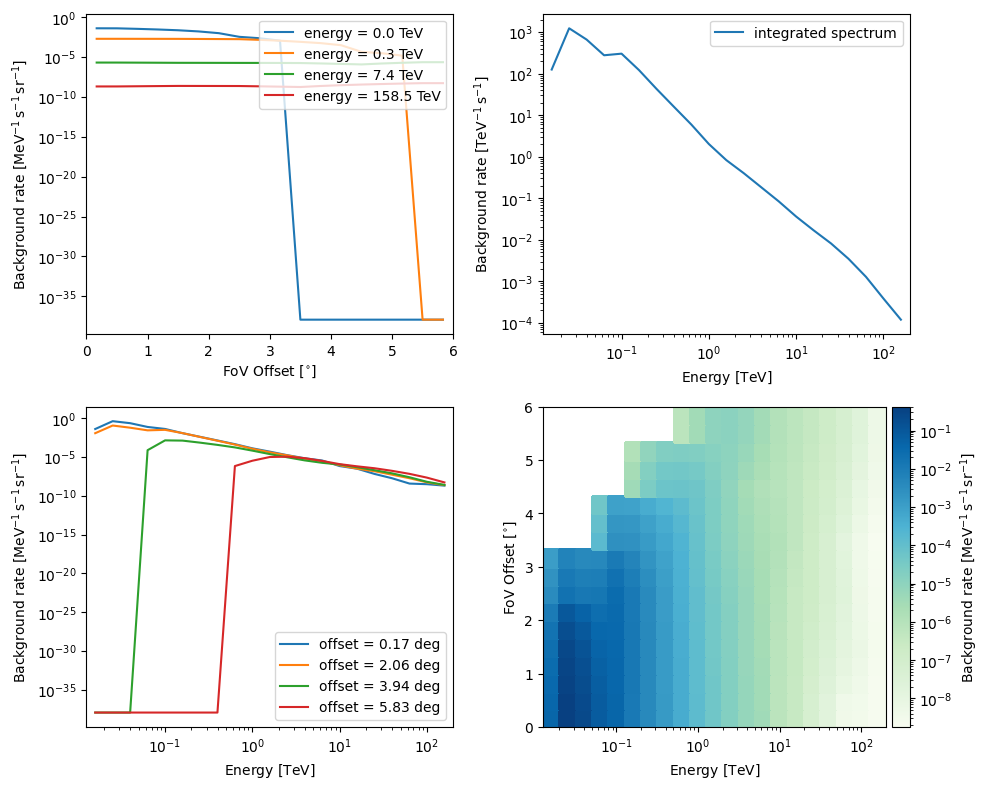

In [22]:
# Data formats not in the registry are still readable if the HDUCLASn is recognized by the registry.
# In this example, the format encoded in the cta-1dc metadata was wrongly set to OGIP, while it is in fact GADF

bkg_ogip = ProductReaderWriter.read("/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits", "BKG") # The user doesn't need to know the precise product class, like Background2D or Background3D

bkg_ogip.peek()

In [23]:
filename_out='./output_file.fits.gz'
prw_2 = ProductReaderWriter(filename, 'EDISP', edisp)
prw_2.write(filename_out, overwrite=True)

2026-07-22 16:37:36,277 gammapy.io.core INFO 
------------------------------------------------
/Users/mcarrasco/Prog/gammapy/gammapy-datasets/dev/hess-dl3-dr1/data/hess_dl3_dr1_obs_id_020136.fits.gz 
TESTED FMT: GADF VER: 0.3 (strict=False)
2026-07-22 16:37:36,284 gammapy.io.core INFO Reading EVENTS HDU
2026-07-22 16:37:36,286 gammapy.io.core INFO Reading GTI HDU
2026-07-22 16:37:36,289 gammapy.io.core INFO Reading RESPONSE HDU (AEFF_2D)
2026-07-22 16:37:36,297 gammapy.io.core INFO Reading RESPONSE HDU (EDISP_2D)
2026-07-22 16:37:36,302 gammapy.io.core INFO Reading RESPONSE HDU (PSF_TABLE)
2026-07-22 16:37:36,309 gammapy.io.core INFO Reading RESPONSE HDU (BKG_3D)
2026-07-22 16:37:36,309 gammapy.io.core INFO 
HDU       FMT  VER HDR TAB
EVENTS    GADF 0.2 OK OK
GTI       GADF 0.2 OK OK
EFF_AREA  GADF 0.2 OK OK
EDISP     GADF 0.2 OK OK
RPSF      GADF 0.2 OK OK
BKG       GADF 0.2 OK OK


2026-07-22 16:37:36,354 gammapy.io.core INFO 
------------------------------------------------
output_file.fits.gz 
TESTED FMT: GADF VER: 0.3 (strict=False)
2026-07-22 16:37:36,360 gammapy.io.core INFO Reading RESPONSE HDU (EDISP_2D)
2026-07-22 16:37:36,360 gammapy.io.core INFO 
HDU      FMT  VER HDR TAB
EDISP    GADF 0.2 OK OK


set()

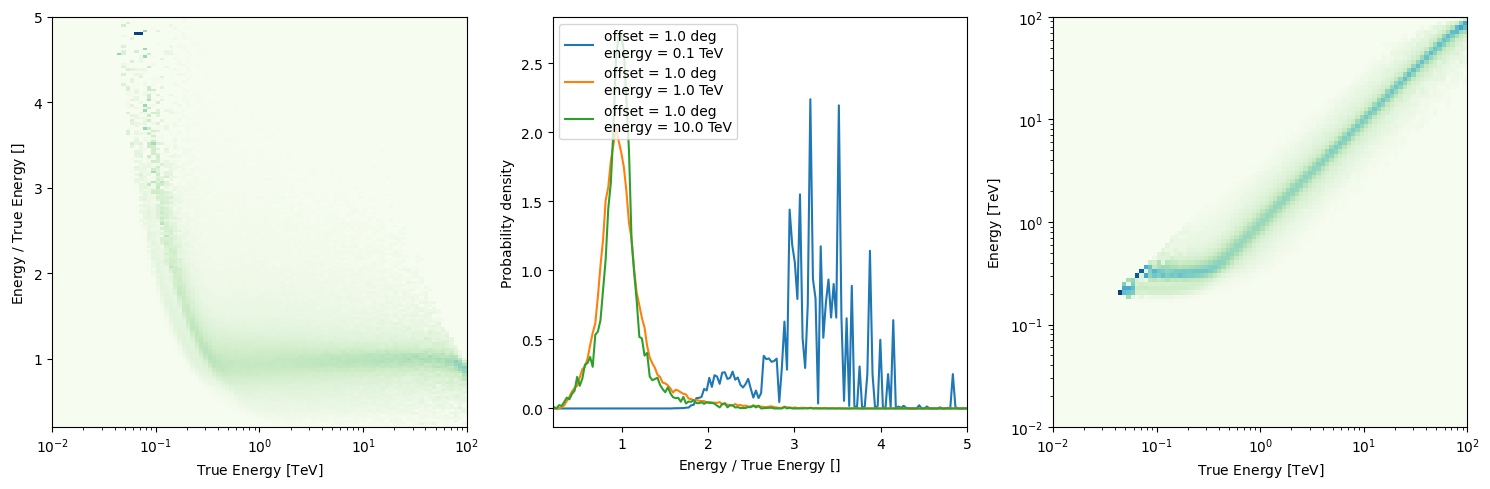

In [24]:
edisp_2 = ProductReaderWriter.read(filename_out, 'EDISP')
edisp_2.peek()
set(edisp.meta) - set(edisp_2.meta)